# US Target Variable Collection Pipeline
---
This notebook collects and compiles US delinquency rate time series to be used as target variables in the macroeconomic model for Probability of Default (PD) prediction.

**Data Source:** FRED (Federal Reserve Bank of St. Louis) via the `fredapi` Python library

**Temporal Frequency:** Quarterly

**Date Convention:** Quarter-end (e.g. 2025-03-31 for Q1 2025)

---
## Variable Reference

### United States (US) - Delinquency Rates

The delinquency rate for any loan category is the ratio of the dollar amount of a bank's delinquent loans in that category to the dollar amount of total loans outstanding in that category ([source](https://www.federalreserve.gov/releases/chargeoff/about.htm)).

| Variable Name | Description | Units | Source | Series ID |
|---|---|---|---|---|
| `us_delinquency_all` | Delinquency rate on all loans, all commercial banks. Headline series - most comprehensive measure of credit stress across the banking system. | %, seasonally adjusted| FRED | [`DRALACBS`](https://fred.stlouisfed.org/series/DRALACBS) |
| `us_delinquency_consumer` | Delinquency rate on consumer loans, all commercial banks. Subset of the headline series covering personal/consumer credit. | %, seasonally adjusted | FRED | [`DRCLACBS`](https://fred.stlouisfed.org/series/DRCLACBS) |
| `us_delinquency_cc` | Delinquency rate on credit card loans, all commercial banks. Subset of consumer loans; tends to be more volatile and lead the cycle. | %, seasonally adjusted | FRED | [`DRCCLACBS`](https://fred.stlouisfed.org/series/DRCCLACBS) |
| `us_delinquency_realestate` | Delinquency rate on loans secured by real estate, all commercial banks. Subset of the headline series; closely linked to housing market conditions. | %, seasonally adjusted | FRED | [`DRSREACBS`](https://fred.stlouisfed.org/series/DRSREACBS) |

**Note:** Series (2), (3), and (4) are subsets of (1). Different macroeconomic variables may have different predictive power depending on the loan category - for example, house prices and bond yields may be more relevant for real estate loans, while unemployment and consumer confidence may be more relevant for consumer and credit card loans.

**Other Useful Links:**

- Overview of delinquency rates - https://fred.stlouisfed.org/graph/?g=f4RZ 
- Release Tables - https://fred.stlouisfed.org/release/tables?rid=231&eid=148469 , https://www.federalreserve.gov/releases/chargeoff/delallsa.htm 

---
## 1. Install & Import Packages

In [1]:
pip install fredapi

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from fredapi import Fred

---
## 2. API Setup

In [4]:
# Load FRED API key from a local text file
with open("fred_api.txt", "r") as f:
    fred_api_key = f.read().strip()

fred = Fred(api_key=fred_api_key)

---
## 3. Fetch Target Variables

All four series are quarterly and reported by FRED. The index is shifted to quarter-end (e.g. 2025-03-31) to reflect that each value represents the full quarter, consistent with the convention used in the macroeconomic data pipeline.

In [6]:
# --- Fetch all four delinquency rate series ---

# Headline: all loans, all commercial banks
us_delinquency_all = fred.get_series('DRALACBS')

# Subset: consumer loans, all commercial banks
us_delinquency_consumer = fred.get_series('DRCLACBS')

# Subset: credit card loans, all commercial banks
us_delinquency_cc = fred.get_series('DRCCLACBS')

# Subset: loans secured by real estate, all commercial banks
us_delinquency_realestate = fred.get_series('DRSREACBS')

# --- Shift index to quarter-end for all series ---
for s in [us_delinquency_all, us_delinquency_consumer,
          us_delinquency_cc, us_delinquency_realestate]:
    s.index = pd.to_datetime(s.index).tz_localize(None)
    s.index = s.index.to_period('Q').to_timestamp('Q').normalize()

# --- Compile into a single DataFrame ---
us_target = pd.DataFrame({
    'us_delinquency_all':        us_delinquency_all,
    'us_delinquency_consumer':   us_delinquency_consumer,
    'us_delinquency_cc':         us_delinquency_cc,
    'us_delinquency_realestate': us_delinquency_realestate,
})

# Drop the current incomplete quarter
current_quarter_end = pd.Timestamp.today().to_period('Q').to_timestamp('Q').normalize()
us_target = us_target[us_target.index < current_quarter_end]

print(f"US Target Variables: {us_target.index.min().date()} to {us_target.index.max().date()}, {len(us_target)} rows")


US Target Variables: 1985-03-31 to 2025-12-31, 164 rows


In [8]:
us_target.tail(20)

,us_delinquency_all,us_delinquency_consumer,us_delinquency_cc,us_delinquency_realestate
2021-03-31,1.47,1.69,1.88,1.84
2021-06-30,1.37,1.53,1.59,1.69
2021-09-30,1.29,1.52,1.53,1.56
2021-12-31,1.26,1.54,1.57,1.50
2022-03-31,1.24,1.65,1.69,1.40
2022-06-30,1.22,1.81,1.83,1.32
2022-09-30,1.20,1.92,2.05,1.21
2022-12-31,1.19,2.07,2.26,1.21
2023-03-31,1.21,2.23,2.47,1.23
2023-06-30,1.26,2.37,2.75,1.26


In [9]:
us_target.head(20)

,us_delinquency_all,us_delinquency_consumer,us_delinquency_cc,us_delinquency_realestate
1985-03-31,4.61,NaN,NaN,NaN
1985-06-30,4.92,NaN,NaN,NaN
1985-09-30,4.91,NaN,NaN,NaN
1985-12-31,4.77,NaN,NaN,NaN
1986-03-31,4.86,NaN,NaN,NaN
1986-06-30,4.74,NaN,NaN,NaN
1986-09-30,4.75,NaN,NaN,NaN
1986-12-31,4.66,NaN,NaN,NaN
1987-03-31,5.63,3.35,NaN,4.97
1987-06-30,5.47,3.28,NaN,4.78


---
## 4. Coverage Audit

Check the start date, end date, and number of non-null observations for each series.

In [10]:
print(f"{'='*60}")
print(f"  Coverage Summary: US Delinquency Rate Series")
print(f"{'='*60}")

summary = pd.DataFrame({
    'First Obs':  us_target.apply(lambda c: c.first_valid_index()),
    'Last Obs':   us_target.apply(lambda c: c.last_valid_index()),
    'N Non-Null': us_target.notna().sum(),
    'N Missing':  us_target.isna().sum(),
})
print(summary.to_string())

  Coverage Summary: US Delinquency Rate Series
                           First Obs   Last Obs  N Non-Null  N Missing
us_delinquency_all        1985-03-31 2025-12-31         164          0
us_delinquency_consumer   1987-03-31 2025-12-31         156          8
us_delinquency_cc         1991-03-31 2025-12-31         140         24
us_delinquency_realestate 1987-03-31 2025-12-31         156          8


---
## 5. Visualisation

Plot all four series together to compare their levels and cyclical behaviour, and individually to inspect each series more closely.

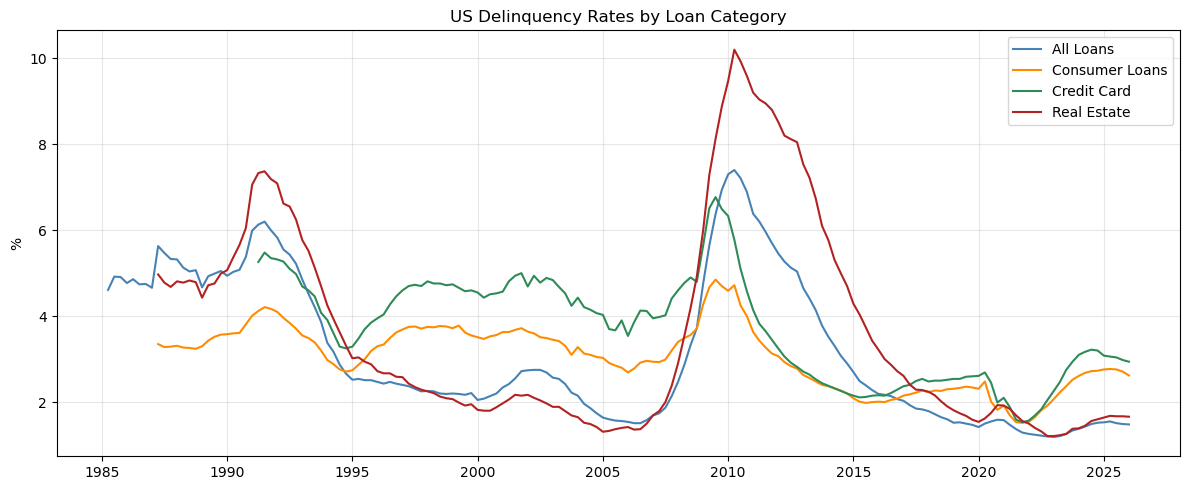

In [11]:
# --- All series on one plot ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(us_target.index, us_target['us_delinquency_all'],        label='All Loans',       color='steelblue')
ax.plot(us_target.index, us_target['us_delinquency_consumer'],   label='Consumer Loans',  color='darkorange')
ax.plot(us_target.index, us_target['us_delinquency_cc'],         label='Credit Card',     color='seagreen')
ax.plot(us_target.index, us_target['us_delinquency_realestate'], label='Real Estate',     color='firebrick')

ax.set_title('US Delinquency Rates by Loan Category')
ax.set_ylabel('%')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

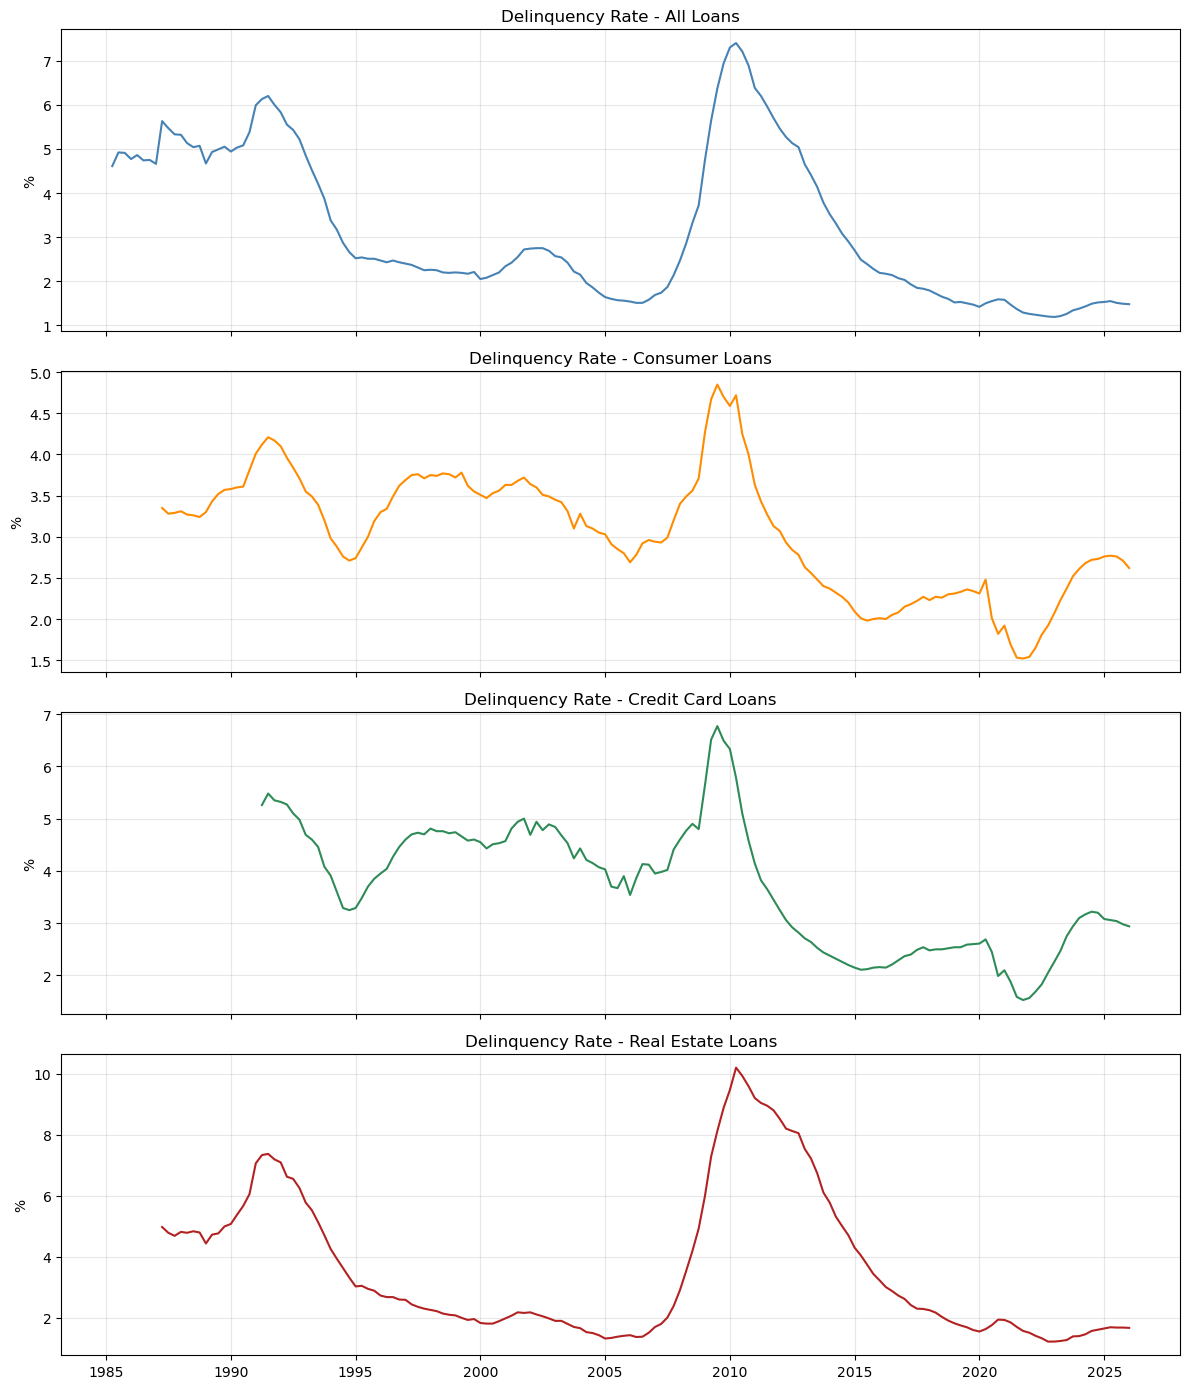

In [13]:
# --- Individual plots for closer inspection ---
series_labels = {
    'us_delinquency_all':        'All Loans',
    'us_delinquency_consumer':   'Consumer Loans',
    'us_delinquency_cc':         'Credit Card Loans',
    'us_delinquency_realestate': 'Real Estate Loans',
}
colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

for i, (col, label) in enumerate(series_labels.items()):
    axes[i].plot(us_target.index, us_target[col], color=colors[i])
    axes[i].set_title(f'Delinquency Rate - {label}')
    axes[i].set_ylabel('%')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Save to CSV

In [14]:
# Set your output directory here
output_dir = os.path.expanduser("~/Desktop")

us_target.to_csv(os.path.join(output_dir, "TargetVariables_US.csv"))

print(f"Saved TargetVariables_US.csv  ({us_target.shape[0]} rows x {us_target.shape[1]} cols)")

Saved TargetVariables_US.csv  (164 rows x 4 cols)
